## Import Dependencies
In this section, we import the necessary libraries for our experiments

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from itertools import product
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn import mixture
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
import networkx as nx
import numpy as np
import torch
from node2vec import Node2Vec
import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/dsa5101/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preparation

In this section, we read in the the data in cora.content as a dataframe and the data in cora.cites as an undirected graph

In [2]:
#create empty undirected graph

G=nx.Graph()

#raw data is directed graph
cites_file='cora/cora.cites'
content_file='cora/cora.content'

#convert raw directed graph into undirected by adding undirected edges to the graph G
#(i.e.paper A and paper B are linked as long as either one of the paper cites the other)

with open(cites_file, 'r') as f:
    for line in f:
        paper1, paper2 = map(int, line.strip().split())
        G.add_edge(paper1, paper2)
        
#sanity check 
if G.is_directed():
    print("The graph is directed.")
else:
    print("The graph is undirected.")
    
#read and assign node features
data = pd.read_csv(content_file, sep='\t', header=None)
for row in data.itertuples():
    node_id = row[1]
    features = row[2:-1]
    label = row[-1]
    G.nodes[node_id]['features'] = features
    G.nodes[node_id]['label'] = label

The graph is undirected.


In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,1128975,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
2704,1128977,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
2705,1128978,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
2706,117328,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based


## Exploratory Data Analysis

In this section, we perform basic exploration on the cora dataset. 

In [4]:
#basic summary statistics on the graph
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
degrees = [degree for _, degree in G.degree()]
average_degree = np.mean(degrees)
density = nx.density(G)
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average degree: {average_degree:.2f}")
print(f"Graph density: {density:.4f}")


Number of nodes: 2708
Number of edges: 5278
Average degree: 3.90
Graph density: 0.0014


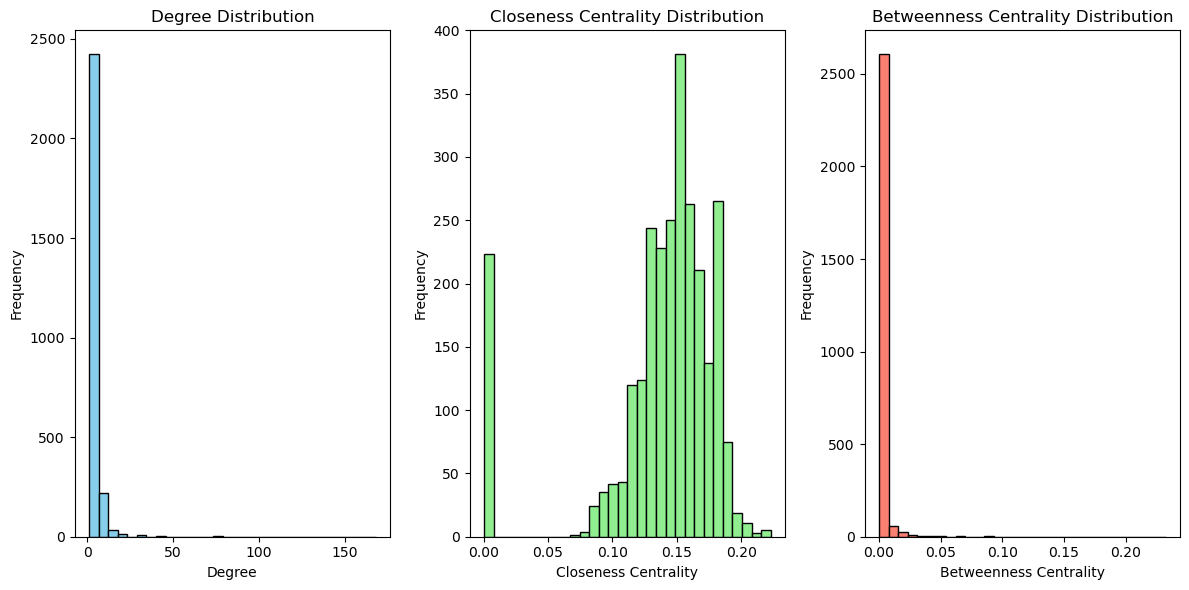

In [5]:
# Plotting Degree Distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(degrees, bins=30, color='skyblue', edgecolor='black')
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')

# Compute and Plot Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)
plt.subplot(1, 3, 2)
plt.hist(list(closeness_centrality.values()), bins=30, color='lightgreen', edgecolor='black')
plt.title('Closeness Centrality Distribution')
plt.xlabel('Closeness Centrality')
plt.ylabel('Frequency')

# Compute and Plot Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
plt.subplot(1, 3, 3)
plt.hist(list(betweenness_centrality.values()), bins=30, color='salmon', edgecolor='black')
plt.title('Betweenness Centrality Distribution')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

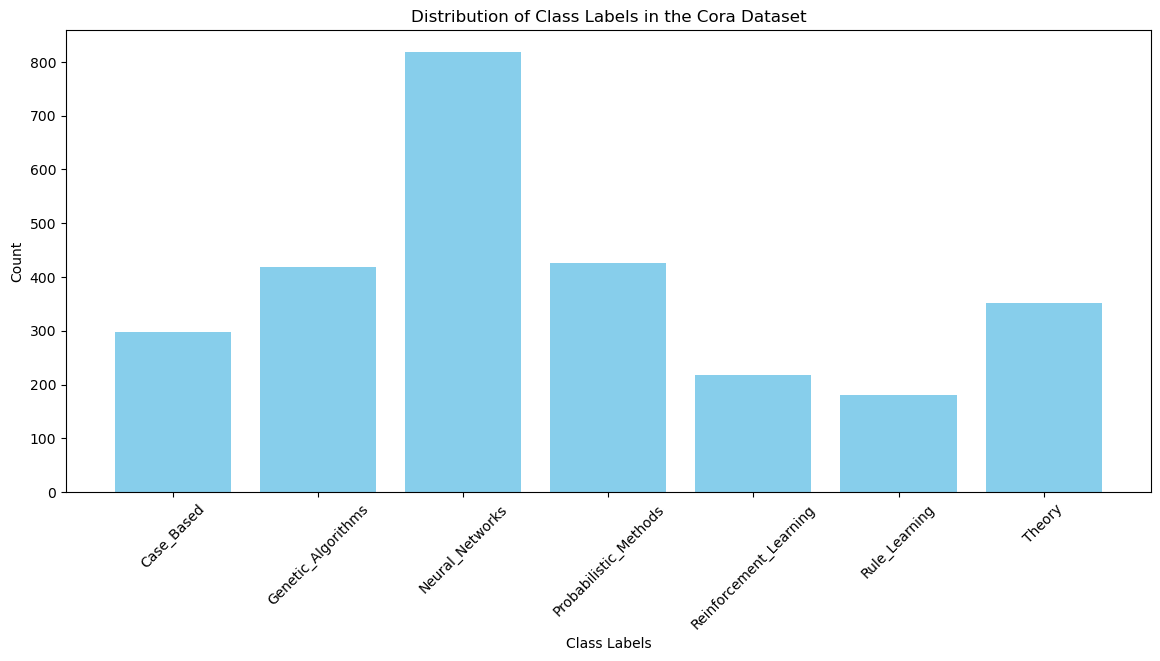

In [6]:
# Distribution of class labels

# Extract class labels from the graph
labels = [data['label'] for _, data in G.nodes(data=True)]

# Get unique labels and their counts
unique_labels, counts = np.unique(labels, return_counts=True)

# Plot the distribution of class labels
plt.figure(figsize=(14, 6))
plt.bar(unique_labels, counts, color='skyblue')
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Distribution of Class Labels in the Cora Dataset")
plt.xticks(rotation=45)
plt.show()


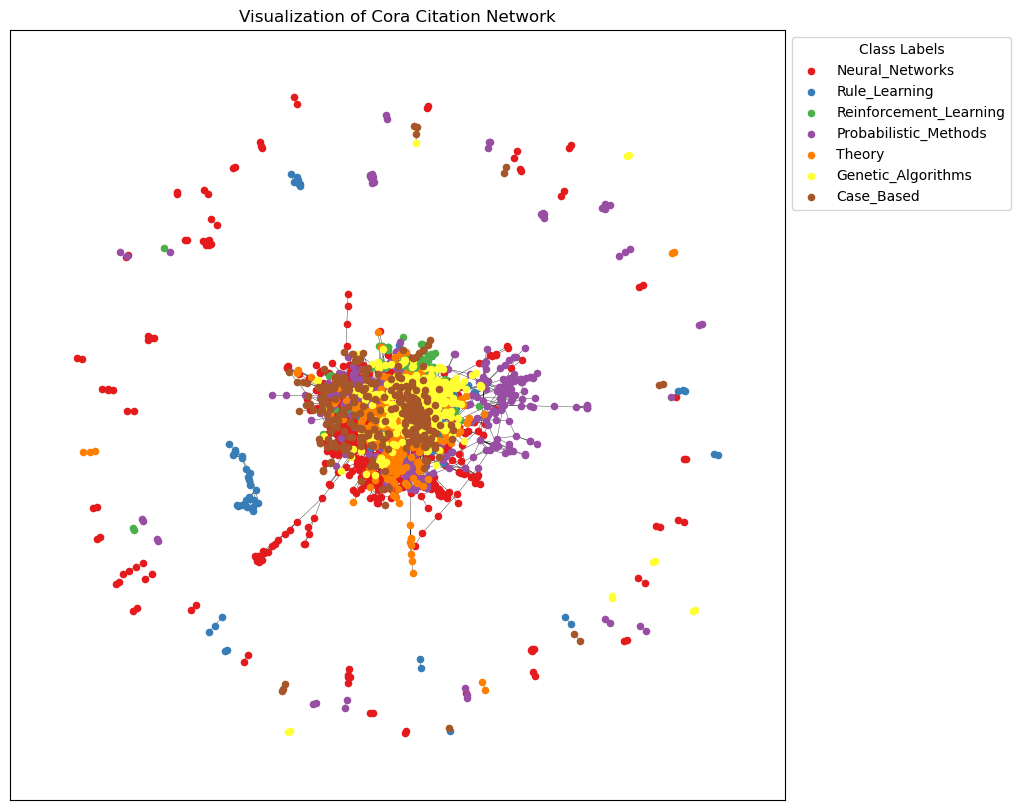

In [7]:
# Define the color list and nodelist for each class (7 classes in total)
colorlist = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628']
nodelist = [[] for _ in range(7)]  # Lists for nodes of each class

# Factorize the labels to convert them to int indices
labels, unique_labels = pd.factorize(data[1434])  

# Populate the nodelist and node_color based on node labels
node_color = []
for node in G.nodes():
    label = labels[data[data[0] == node].index[0]]  # Get the label for the node from DataFrame
    node_color.append(colorlist[label])  # Append color based on label
    nodelist[label].append(node)  # Append node ID to corresponding class

# Generate node positions using spring layout 
pos = nx.spring_layout(G, seed=42)  

plt.figure(figsize=(10, 10))

# Draw nodes for each class, with different colors and smaller node size
for num, nodes in enumerate(nodelist):
    if len(nodes) > 0:  
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_size=20, node_color=colorlist[num], label=unique_labels[num])

# Draw edges
nx.draw_networkx_edges(G, pos, width=0.25)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title="Class Labels")
plt.title("Visualization of Cora Citation Network")
plt.show()


<Axes: >

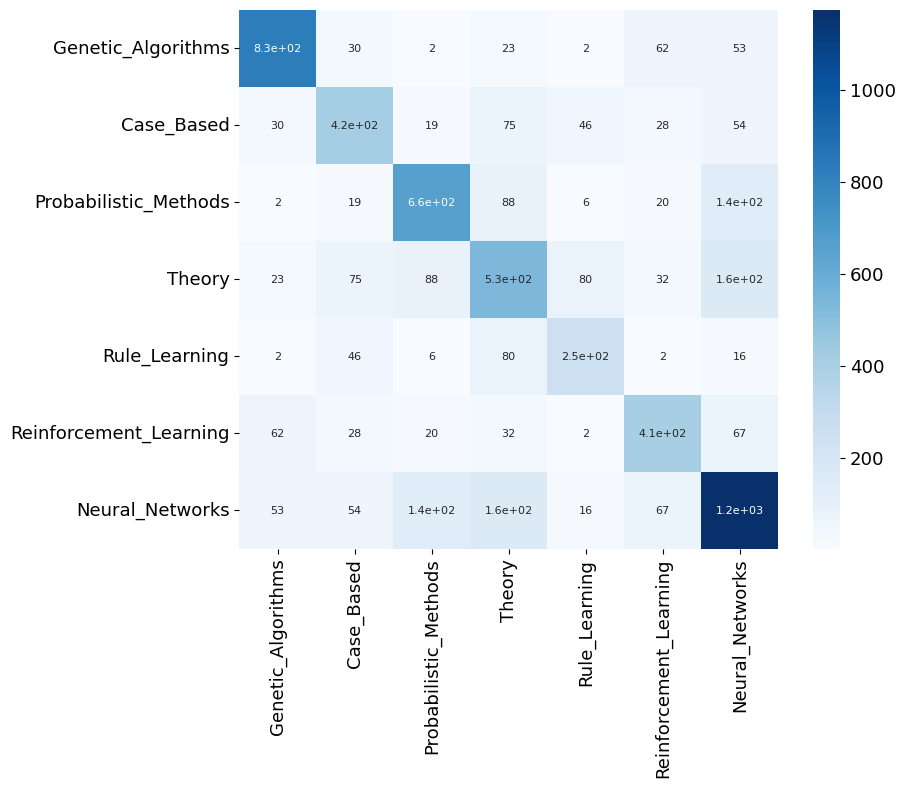

In [8]:
#Extract labels and create a mapping from label to integer index
labels = nx.get_node_attributes(G, 'label')

# Get unique labels and create a mapping to integers
unique_labels = list(set(labels.values()))  # Get unique label values
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}  # Map labels to integers

#Create a 2D array to store counts of edges between nodes of different labels
num_labels = len(unique_labels)
label_connection_counts = np.zeros((num_labels, num_labels))

#Iterate over all edges in the graph
for (node1, node2) in G.edges():
    label1 = label_to_index[labels[node1]]  # Map label to index
    label2 = label_to_index[labels[node2]]  # Map label to index
    # Increment the corresponding position in the matrix
    label_connection_counts[label1, label2] += 1
    if label1 != label2:  
        label_connection_counts[label2, label1] += 1

#Create a heatmap of the connection counts between different labels
plt.figure(figsize=(9, 7))
plt.rcParams["font.size"] = 13

# Plot the heatmap
sb.heatmap(label_connection_counts, annot=True, cmap='Blues', cbar=True, square=True,
            xticklabels=unique_labels, yticklabels=unique_labels,
            annot_kws={"size": 8}) 


## Experiments
In this section, we first implement elbow plot to decide on the number of clusters, followed by the implementation of a function that contains of the set of metrics used for evaluation. Finally, we train all 3 models (i.e. KMeans, GMM, Hierarchical clustering) with different input embeddings (i.e. Bag-of-Words, Node2Vec) and evaluate the trained models based on the set of evaluation metrics.  

#### Elbow Method to find optimal K

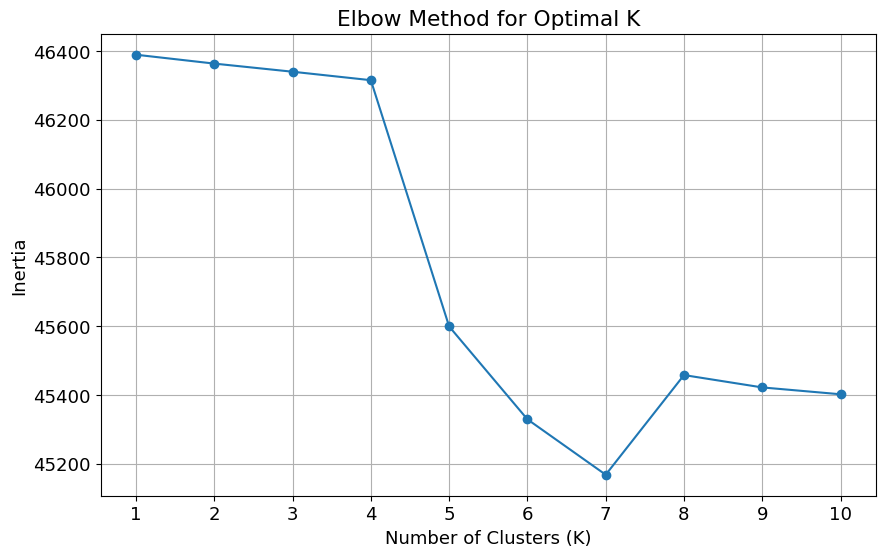

In [9]:
# find optimal K using elbow plot

features = np.array([G.nodes[n]['features'] for n in G.nodes()])
inertia = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)  
    inertia.append(kmeans.inertia_)  

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid()
plt.show()


#### Evaluation Metrics


In [10]:

"""
Evaluates clustering quality with Within-Cluster SS, Between-Cluster SS, and Purity

Parameters:
X : array-like, shape (n_samples, n_features)
    Feature matrix.
labels : array-like, shape (n_samples,)
    Predicted cluster labels (integers) for each sample.
ground_truth : array-like, shape (n_samples,), optional
    True labels (strings) to compute Purity.

Returns:
metrics : dict
    Dictionary containing WCSS, BCSS, and Purity 
"""
def clustering_evaluation(X, labels, ground_truth=None):
    
    metrics = {}
    
    # Calculate centroids
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == label].mean(axis=0) for label in unique_labels])
    
    # 1. Within-Cluster Sum of Squares (WCSS)
    wcss = sum(
        np.sum((X[labels == label] - centroid) ** 2) for label, centroid in zip(unique_labels, centroids)
    )
    metrics['Within-Cluster SS (WCSS)'] = wcss

    # 2. Between-Cluster Sum of Squares (BCSS)
    overall_mean = X.mean(axis=0)
    bcss = sum(
        len(X[labels == label]) * np.sum((centroid - overall_mean) ** 2) for label, centroid in zip(unique_labels, centroids)
    )
    metrics['Between-Cluster SS (BCSS)'] = bcss

    # 3. Purity 
    if ground_truth is not None:
        # Map predicted labels to consecutive integers
        label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
        # Map string ground truth labels to consecutive integers
        ground_truth_unique = np.unique(ground_truth)
        ground_truth_to_index = {label: idx for idx, label in enumerate(ground_truth_unique)}
        
        # Create contingency matrix
        contingency_matrix = np.zeros((len(unique_labels), len(ground_truth_unique)), dtype=int)
        for i in range(len(labels)):
            label_idx = label_to_index[labels[i]]
            gt_idx = ground_truth_to_index[ground_truth[i]]
            contingency_matrix[label_idx, gt_idx] += 1
        
        # Calculate purity
        purity = np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)
        metrics['Purity'] = purity
    
    return metrics


#### Node2Vec Embeddings

In [11]:
# Extract original features and labels
original_features = np.array([G.nodes[node]['features'] for node in G.nodes()])
labels = np.array([G.nodes[node]['label'] for node in G.nodes()])

# Define embedding generation function
def generate_node2vec_embeddings(graph, dimensions=128, walk_length=30, num_walks=200, p=1, q=1):
    node2vec = Node2Vec(graph, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, p=p, q=q, workers=4)
    model = node2vec.fit(window=10, min_count=1, batch_words=4)
    return model

# Generate embeddings
node2vec_model = generate_node2vec_embeddings(G)

# Extract embeddings for each node
node2vec_embeddings = np.array([node2vec_model.wv[str(node)] for node in G.nodes()])


Computing transition probabilities: 100%|█| 2708/2708 [00:00<00:00, 14780.86it/s
Generating walks (CPU: 4): 100%|██████████| 50/50 [00:07<00:00,  6.95it/s]


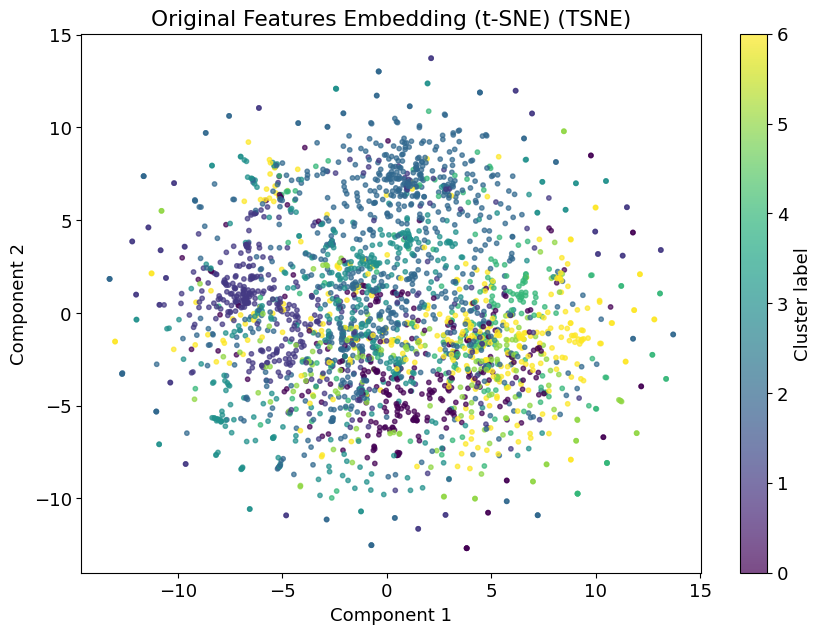

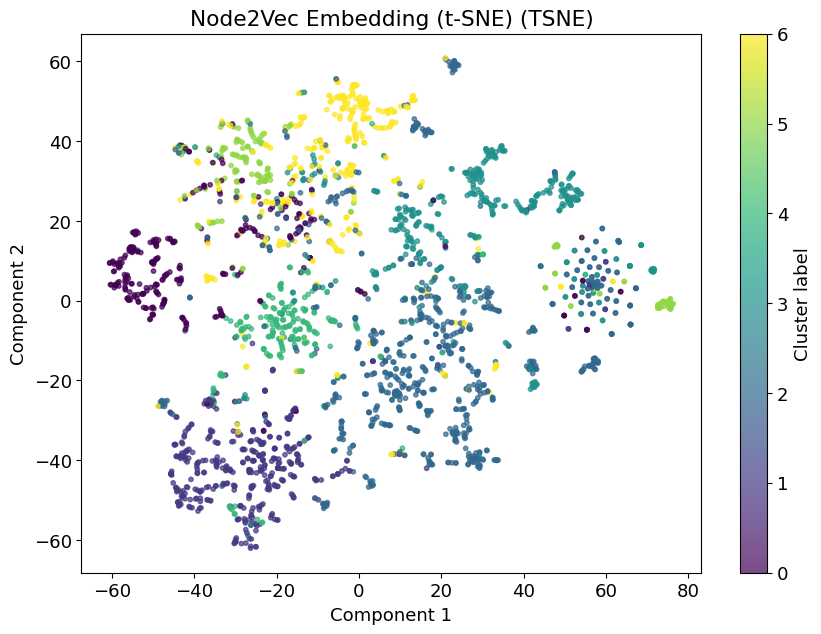

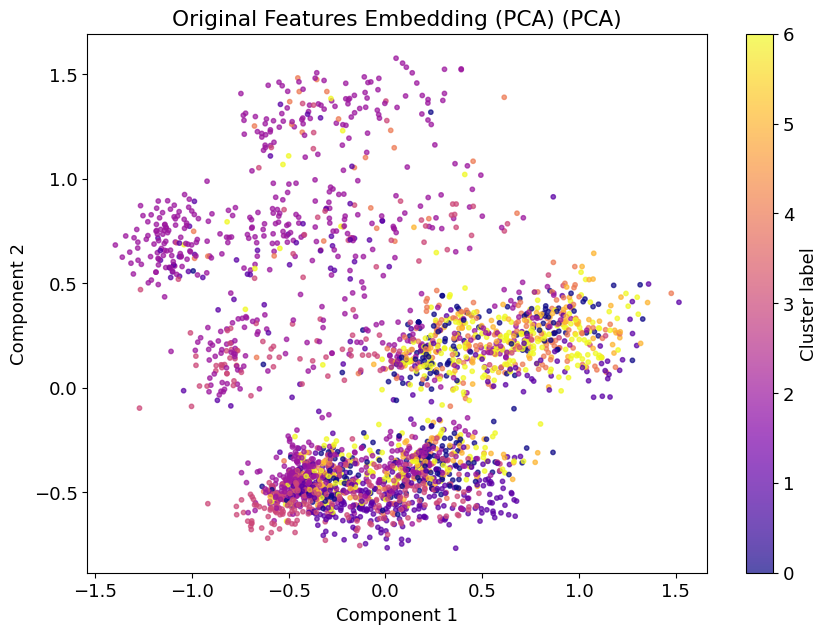

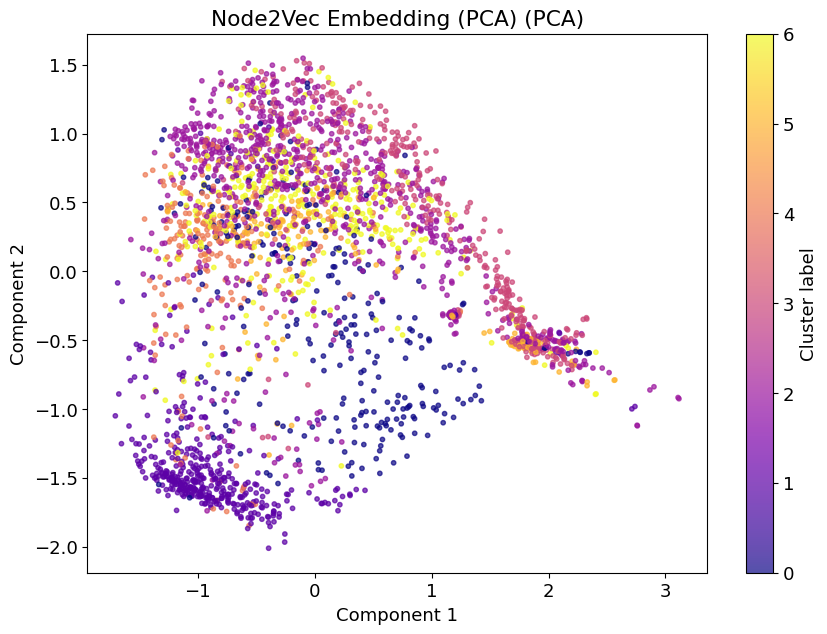

In [19]:
# Function to visualize Bag-of-Words and Node2Vec embedding spaces 
def visualize_embeddings(embeddings, labels, title, method='tsne', color_map='viridis'):
    # Dimensionality reduction
    if method == 'tsne':
        reduced_embeddings = TSNE(n_components=2, random_state=42).fit_transform(embeddings)
    elif method == 'pca':
        reduced_embeddings = PCA(n_components=2).fit_transform(embeddings)
    
    # Plot the reduced embeddings
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels, cmap=color_map, s=10, alpha=0.7)
    plt.colorbar(scatter, label="Cluster label")
    plt.title(f"{title} ({method.upper()})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# Encode labels as numeric for coloring
label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(labels)

# Visualize with different color schemes for PCA and t-SNE
# t-SNE with 'viridis' colormap
visualize_embeddings(original_features, numeric_labels, "Original Features Embedding (t-SNE)", method='tsne', color_map='viridis')
visualize_embeddings(node2vec_embeddings, numeric_labels, "Node2Vec Embedding (t-SNE)", method='tsne', color_map='viridis')

# PCA with 'plasma' colormap
visualize_embeddings(original_features, numeric_labels, "Original Features Embedding (PCA)", method='pca', color_map='plasma')
visualize_embeddings(node2vec_embeddings, numeric_labels, "Node2Vec Embedding (PCA)", method='pca', color_map='plasma')


#### KMeans 
Here, we train the KMeans model with both BoW embeddings and Node2Vec embeddings

In [20]:
#KMeans Clustering
n_clusters = 7

# Apply KMeans on original features (BoW embeddings)
kmeans_original = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(original_features)
metrics_original = clustering_evaluation(original_features, kmeans_original, labels)
print("Original Features:")
print(metrics_original)

# Apply KMeans on Node2Vec embeddings
kmeans_node2vec = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(node2vec_embeddings)
metrics_node2vec = clustering_evaluation(node2vec_embeddings, kmeans_node2vec, labels)
print("Node2Vec Embeddings:")
print(metrics_node2vec)


Original Features:
{'Within-Cluster SS (WCSS)': 45167.89963061195, 'Between-Cluster SS (BCSS)': 1221.6232645136129, 'Purity': 0.5528064992614475}
Node2Vec Embeddings:
{'Within-Cluster SS (WCSS)': 29223.035034179688, 'Between-Cluster SS (BCSS)': 6810.422892570496, 'Purity': 0.5646233382570163}


#### Hierarchical Clustering
Here, we train the hierarchical clustering model with both BoW embeddings and Node2Vec embeddings

In [21]:
# Hierarchical Clustering
n_clusters = 7

# Apply hierarchical clustering on original features (BoW embeddings)
hierarchical_original = AgglomerativeClustering(n_clusters=n_clusters,linkage='average').fit_predict(original_features)
metrics_original = clustering_evaluation(original_features, hierarchical_original, labels)
print("Original Features:")
print(metrics_original)

# Apply hierarchical clustering on Node2Vec embeddings
hierarchical_node2vec = AgglomerativeClustering(n_clusters=n_clusters,linkage='average').fit_predict(node2vec_embeddings)
metrics_node2vec = clustering_evaluation(node2vec_embeddings, hierarchical_node2vec, labels)
print("Node2Vec Embeddings:")
print(metrics_node2vec)


Original Features:
{'Within-Cluster SS (WCSS)': 46230.9881569208, 'Between-Cluster SS (BCSS)': 158.53473820475452, 'Purity': 0.9977843426883308}
Node2Vec Embeddings:
{'Within-Cluster SS (WCSS)': 35483.79803738929, 'Between-Cluster SS (BCSS)': 549.6579028973356, 'Purity': 0.9896602658788775}


#### Gaussian Mixture Model Clustering

Here, we train the gmm clustering model with both BoW embeddings and Node2Vec embeddings

In [22]:
# GMM Clustering
n_clusters = 7

# Apply GMM on original features (BoW embeddings)
gmm_original= mixture.GaussianMixture(n_components=n_clusters, random_state=42).fit_predict(original_features)
metrics_original = clustering_evaluation(original_features, gmm_original, labels)
print("Original Features:")
print(metrics_original)

# Apply GMM on Node2Vec embeddings
gmm_node2vec = mixture.GaussianMixture(n_components=n_clusters, random_state=42).fit_predict(node2vec_embeddings)
metrics_node2vec = clustering_evaluation(node2vec_embeddings, gmm_node2vec, labels)
print("Node2Vec Embeddings:")
print(metrics_node2vec)


Original Features:
{'Within-Cluster SS (WCSS)': 45167.89963061195, 'Between-Cluster SS (BCSS)': 1221.6232645136129, 'Purity': 0.5528064992614475}
Node2Vec Embeddings:
{'Within-Cluster SS (WCSS)': 29232.633911132812, 'Between-Cluster SS (BCSS)': 6800.823828339577, 'Purity': 0.5664697193500738}
